In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

In [ ]:
X, y = make_blobs(
    n_samples=300,
    centers=4,
    cluster_std=0.60,
    random_state=42
)

print("Dataset shape:", X.shape)

Dataset shape: (300, 2)


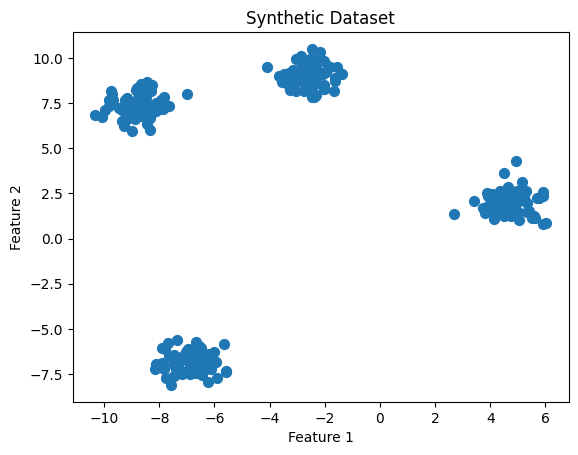

In [ ]:
plt.scatter(X[:,0], X[:,1], s=50)
plt.title("Synthetic Dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

In [ ]:
kmeans = KMeans(n_clusters=4, random_state=42)

kmeans.fit(X)

labels = kmeans.labels_

centers = kmeans.cluster_centers_

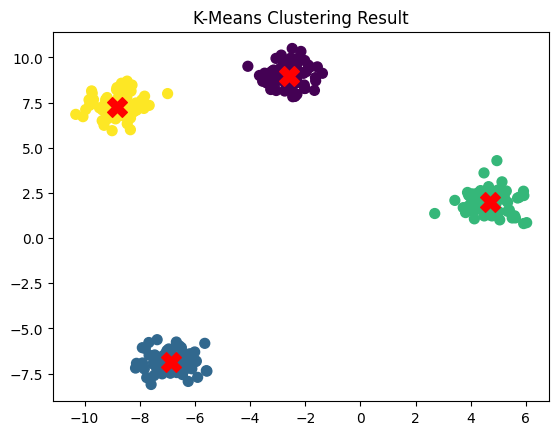

In [ ]:
plt.scatter(X[:,0], X[:,1], c=labels, s=50, cmap='viridis')

plt.scatter(
    centers[:,0],
    centers[:,1],
    c='red',
    s=200,
    marker='X'
)

plt.title("K-Means Clustering Result")
plt.show()

In [ ]:
from sklearn.metrics import pairwise_distances_argmin

def find_clusters(X, n_clusters, rseed=2):

    rng = np.random.RandomState(rseed)

    i = rng.permutation(X.shape[0])[:n_clusters]

    centers = X[i]

    while True:

        labels = pairwise_distances_argmin(X, centers)

        new_centers = np.array([
            X[labels == i].mean(0)
            for i in range(n_clusters)
        ])

        if np.all(centers == new_centers):
            break

        centers = new_centers

    return centers, labels

In [ ]:
centers, labels = find_clusters(X, 4)

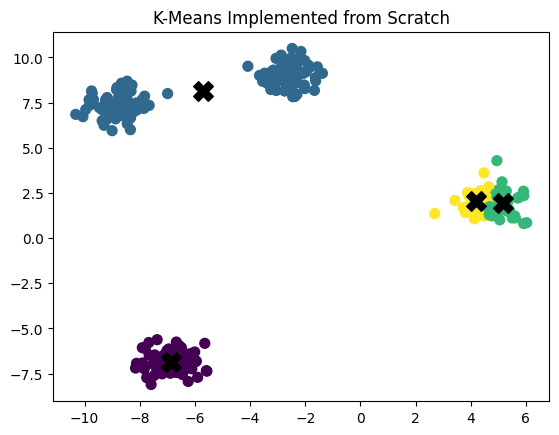

In [ ]:
plt.scatter(X[:,0], X[:,1], c=labels, s=50, cmap='viridis')

plt.scatter(
    centers[:,0],
    centers[:,1],
    c='black',
    s=200,
    marker='X'
)

plt.title("K-Means Implemented from Scratch")
plt.show()

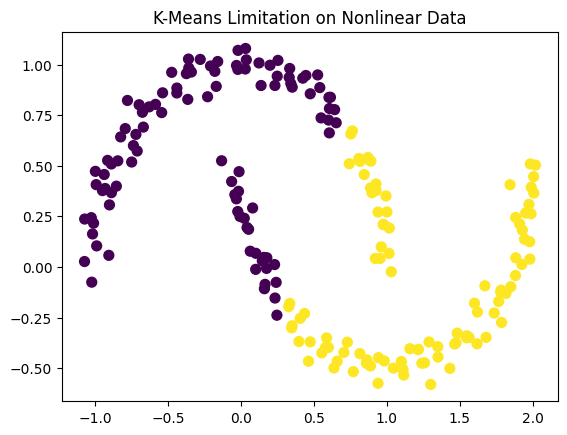

In [ ]:
from sklearn.datasets import make_moons

X_moon, y_moon = make_moons(200, noise=0.05, random_state=0)

labels = KMeans(2, random_state=0).fit_predict(X_moon)

plt.scatter(X_moon[:,0], X_moon[:,1], c=labels, s=50, cmap='viridis')

plt.title("K-Means Limitation on Nonlinear Data")
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


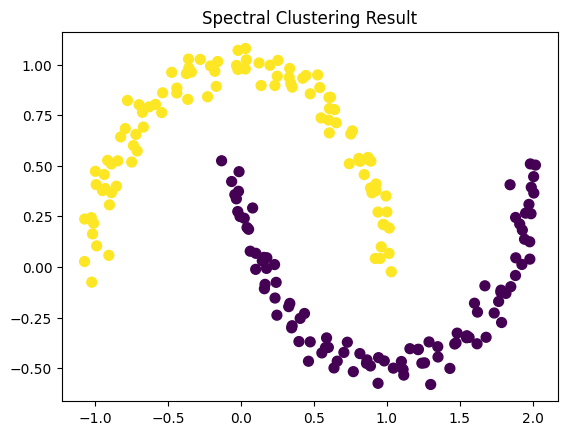

In [ ]:
from sklearn.cluster import SpectralClustering

model = SpectralClustering(
    n_clusters=2,
    affinity='nearest_neighbors',
    assign_labels='kmeans'
)

labels = model.fit_predict(X_moon)

plt.scatter(X_moon[:,0], X_moon[:,1], c=labels, s=50, cmap='viridis')

plt.title("Spectral Clustering Result")
plt.show()

**bold text**
on iris dataset

In [ ]:
from sklearn.datasets import load_iris

iris = load_iris()

X = iris.data
y = iris.target

print("Dataset shape:", X.shape)

Dataset shape: (150, 4)


In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)

kmeans.fit(X)

labels = kmeans.labels_

centers = kmeans.cluster_centers_

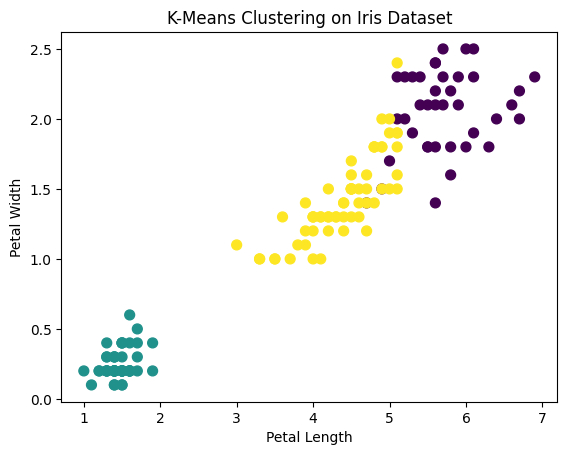

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(
    X[:,2],
    X[:,3],
    c=labels,
    cmap='viridis',
    s=50
)

plt.xlabel("Petal Length")
plt.ylabel("Petal Width")

plt.title("K-Means Clustering on Iris Dataset")

plt.show()

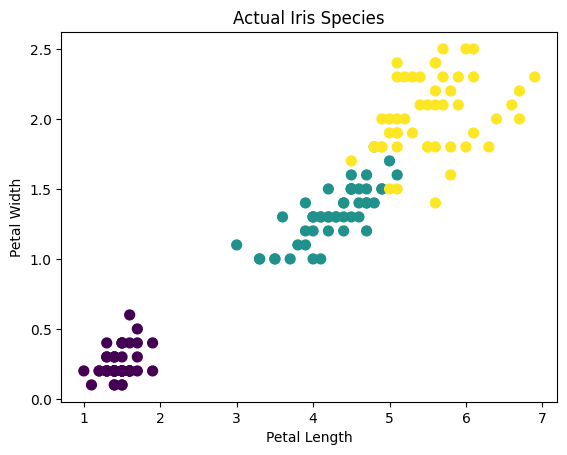

In [ ]:
plt.scatter(
    X[:,2],
    X[:,3],
    c=y,
    cmap='viridis',
    s=50
)

plt.xlabel("Petal Length")
plt.ylabel("Petal Width")

plt.title("Actual Iris Species")

plt.show()